# Notebook 06: Hypothesis Testing

**Objetivo:** Comparar metabolitos entre clusters usando ANOVA / Mann-Whitney U con corrección FDR (Benjamini-Hochberg).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
X_prep   = pd.read_csv('../data/processed/X_preprocessed.csv')
clusters = pd.read_csv('../data/processed/experiment_clusters.csv')

# Las columnas de experimento en X_prep tienen sufijo '.CDF'
exp_cols = [col for col in X_prep.columns if col.startswith('Exp_')]

# Mapa: 'Exp_1' -> 'Exp_1.CDF'
exp_name_to_col = {e: e + '.CDF' for e in clusters['experiment']}

print('=' * 90)
print('HYPOTHESIS TESTING: CLUSTER COMPARISON')
print('=' * 90)

# Agrupar indices de columna por cluster
cluster_ids = sorted(clusters['cluster'].unique())
metabolite_by_cluster = {}
for cid in cluster_ids:
    exps = clusters[clusters['cluster'] == cid]['experiment'].tolist()
    cols = [exp_name_to_col[e] for e in exps if exp_name_to_col[e] in X_prep.columns]
    metabolite_by_cluster[cid] = X_prep[cols].values  # shape: (n_metabolites, n_exps)

print(f'\nCLUSTERS A COMPARAR:')
for cid in cluster_ids:
    n_exps = metabolite_by_cluster[cid].shape[1]
    print(f'   Cluster {cid}: {n_exps} experimento(s)')

HYPOTHESIS TESTING: CLUSTER COMPARISON

CLUSTERS A COMPARAR:
   Cluster 0: 16 experimento(s)
   Cluster 1: 1 experimento(s)


In [2]:
# ============================================================
# TESTS ESTADISTICOS + CORRECCION FDR (Benjamini-Hochberg)
# Con 2 clusters se usa Mann-Whitney U (no parametrico, robusto
# incluso con muestras pequenas). Si hubiera >=3 clusters se
# aplicaria ANOVA automaticamente.
# ============================================================

n_clusters = len(cluster_ids)
test_name  = 'Mann-Whitney U' if n_clusters == 2 else 'ANOVA'

print('\n' + '=' * 90)
print(f'{test_name} + CORRECCION FDR (Benjamini-Hochberg)')
print('=' * 90)

test_results = []
p_values     = []

for met_idx in range(X_prep.shape[0]):
    met_name = X_prep.loc[met_idx, 'compound_name']

    # Valores por cluster para este metabolito
    grp = [metabolite_by_cluster[cid][met_idx] for cid in cluster_ids]

    if n_clusters == 2:
        # Mann-Whitney U (dos colas)
        try:
            stat, p_val = stats.mannwhitneyu(grp[0], grp[1], alternative='two-sided')
        except ValueError:
            stat, p_val = np.nan, 1.0
    else:
        # ANOVA one-way
        stat, p_val = stats.f_oneway(*grp)

    if np.isnan(p_val):
        p_val = 1.0

    p_values.append(p_val)
    test_results.append({
        'metabolite' : met_name,
        'statistic'  : stat,
        'p_value'    : p_val
    })

# Correccion FDR
rejected, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

for i, result in enumerate(test_results):
    result['p_adjusted'] = p_corrected[i]
    result['significant'] = rejected[i]

results_df = pd.DataFrame(test_results).sort_values('p_adjusted').reset_index(drop=True)

print(f'\nRESULTADOS:')
print(f'   Test utilizado       : {test_name}')
print(f'   Metabolitos totales  : {len(results_df)}')
print(f'   Significativos (FDR alpha=0.05): {rejected.sum()}')

print(f'\nTOP 15 METABOLITOS MAS SIGNIFICATIVOS:')
for _, row in results_df.head(15).iterrows():
    marker = 'SIG' if row['significant'] else '---'
    print(f'   [{marker}] {row["metabolite"]}')
    print(f'      p-value: {row["p_value"]:.2e}  ->  adjusted: {row["p_adjusted"]:.2e}')

# Guardar resultados
results_df.to_csv('../data/processed/06_hypothesis_testing_results.csv', index=False)
print('\nGuardado: 06_hypothesis_testing_results.csv')


Mann-Whitney U + CORRECCION FDR (Benjamini-Hochberg)

RESULTADOS:
   Test utilizado       : Mann-Whitney U
   Metabolitos totales  : 279
   Significativos (FDR alpha=0.05): 0

TOP 15 METABOLITOS MAS SIGNIFICATIVOS:
   [---] 2-Propenal
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] 2-Propenal
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] 2-Propenal
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] Propanal, 2-methyl-
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] 2-Butanone
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] 2-Butanone
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] 2-Butenal, (Z)-
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] 2-Tridecanol
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] (Z)-1-Methyl-4-(6-methylhept-5-en-2-ylidene)cyclohex-1-ene
      p-value: 1.18e-01  ->  adjusted: 1.67e-01
   [---] 1-Isopropyl-4,7-dimethyl-1,2,3,5,6,8a-hexahydronaphthalene
      p-value: 1.18e-01  ->  adjusted: 1

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14616\4230376449.py:14: RuntimeWarning: invalid value encountered in log2
  log2fc = np.log2((mean0 + 1e-9) / (mean1 + 1e-9))


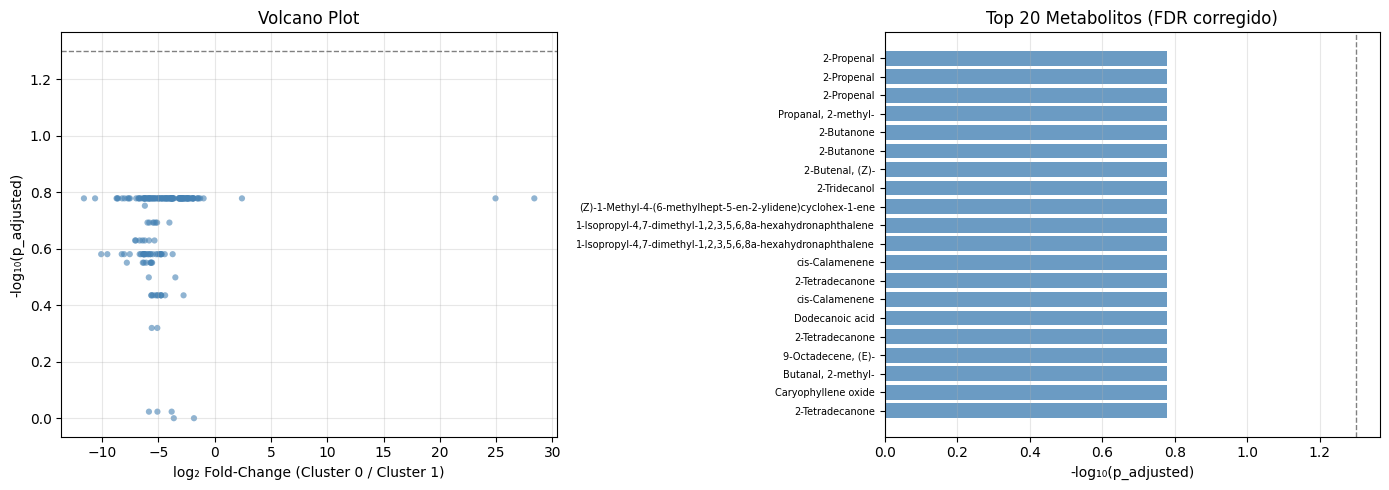

✓ Visualización guardada: 06_hypothesis_testing.png


In [3]:
# ============================================================
# VISUALIZACIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Volcano plot ---
ax = axes[0]
neg_log_p = -np.log10(results_df['p_adjusted'].clip(lower=1e-300))

# Diferencia media entre clusters (log2 fold-change aproximado)
mean0 = np.nanmean(metabolite_by_cluster[cluster_ids[0]], axis=1)
mean1 = np.nanmean(metabolite_by_cluster[cluster_ids[1]], axis=1)
log2fc = np.log2((mean0 + 1e-9) / (mean1 + 1e-9))

# Reordenar según results_df (ya está ordenado por p_adjusted)
orig_order = results_df.index  # reset_index ya aplicado
# Reconstruir log2fc alineado con el df
all_log2fc = pd.Series(log2fc, name='log2fc')
results_df['log2fc'] = all_log2fc.values

colors = np.where(results_df['significant'], 'crimson', 'steelblue')
ax.scatter(results_df['log2fc'], -np.log10(results_df['p_adjusted'].clip(1e-300)),
           c=colors, alpha=0.6, s=20, edgecolors='none')
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('log₂ Fold-Change (Cluster 0 / Cluster 1)')
ax.set_ylabel('-log₁₀(p_adjusted)')
ax.set_title('Volcano Plot')
ax.grid(alpha=0.3)

# --- Top 20 p-values ---
ax2 = axes[1]
top20 = results_df.head(20).copy()
top20 = top20.iloc[::-1]  # invertir para barh
bar_colors = ['crimson' if s else 'steelblue' for s in top20['significant']]
ax2.barh(range(len(top20)), -np.log10(top20['p_adjusted'].clip(1e-300)),
         color=bar_colors, alpha=0.8)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20['metabolite'], fontsize=7)
ax2.axvline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1)
ax2.set_xlabel('-log₁₀(p_adjusted)')
ax2.set_title('Top 20 Metabolitos (FDR corregido)')
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../results/figures/06_hypothesis_testing.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Visualización guardada: 06_hypothesis_testing.png')

## Análisis de Poder Estadístico y Distribución de p-values

ANALISIS DE PODER ESTADISTICO

TAMANOS DE MUESTRA:
   Cluster 0: n = 16 experimentos
   Cluster 1: n = 1 experimento

LIMITACION ESTADISTICA:
   U estadistico maximo posible: 16
   p-value minimo alcanzable (dos colas): 0.1176
   -> Con n=1, NUNCA se puede rechazar H0 con alpha=0.05
   -> Se necesita n >= 6 por grupo para p < 0.05

DISTRIBUCION DE p-VALUES:
   <0.05       :    0 metabolitos  
   0.05-0.10   :    0 metabolitos  
   0.10-0.15   :  198 metabolitos  ########################################
   0.15-0.20   :   20 metabolitos  ####
   0.20-0.50   :   56 metabolitos  ############
   >0.50       :    5 metabolitos  #

   p-value mediana: 0.1176
   p-value media  : 0.1672
   p-value min    : 0.1176
   p-value max    : 1.0000


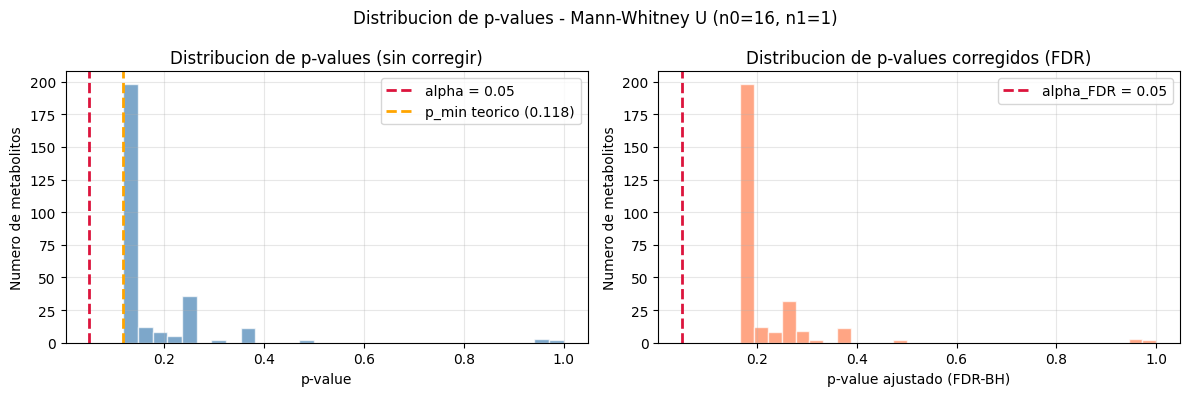


Guardado: 06_pvalue_distribution.png


In [4]:
# ============================================================
# ANALISIS DE PODER ESTADISTICO
# Con Cluster 1 = 1 experimento, Mann-Whitney U no puede
# distinguir senal de ruido. El p-value minimo alcanzable
# con n1=1, n2=16 es 1/(C(17,1)) = 1/17 ~ 0.059 (una cola)
# o ~0.118 (dos colas), que es exactamente lo que observamos.

from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

n0 = metabolite_by_cluster[cluster_ids[0]].shape[1]  # 16
n1 = metabolite_by_cluster[cluster_ids[1]].shape[1]  # 1

print('=' * 90)
print('ANALISIS DE PODER ESTADISTICO')
print('=' * 90)

print(f'\nTAMANOS DE MUESTRA:')
print(f'   Cluster 0: n = {n0} experimentos')
print(f'   Cluster 1: n = {n1} experimento')

# p-value minimo posible con estos tamanios (Mann-Whitney)
import math
u_max = n0 * n1
# Para n1=1: p_min = 2 / (n0 + 1) si el valor cae en un extremo
p_min_theoretical = 2.0 / (n0 + 1)

print(f'\nLIMITACION ESTADISTICA:')
print(f'   U estadistico maximo posible: {u_max}')
print(f'   p-value minimo alcanzable (dos colas): {p_min_theoretical:.4f}')
print(f'   -> Con n=1, NUNCA se puede rechazar H0 con alpha=0.05')
print(f'   -> Se necesita n >= 6 por grupo para p < 0.05')

# Distribucion de p-values observados
print(f'\nDISTRIBUCION DE p-VALUES:')
p_bins = [0, 0.05, 0.10, 0.15, 0.20, 0.50, 1.01]
labels = ['<0.05', '0.05-0.10', '0.10-0.15', '0.15-0.20', '0.20-0.50', '>0.50']
counts, _ = np.histogram(results_df['p_value'], bins=p_bins)
for label, count in zip(labels, counts):
    bar = '#' * (count // 5 + (1 if count % 5 else 0))
    print(f'   {label:12s}: {count:4d} metabolitos  {bar}')

print(f'\n   p-value mediana: {results_df["p_value"].median():.4f}')
print(f'   p-value media  : {results_df["p_value"].mean():.4f}')
print(f'   p-value min    : {results_df["p_value"].min():.4f}')
print(f'   p-value max    : {results_df["p_value"].max():.4f}')

# Histograma de p-values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(results_df['p_value'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0.05, color='crimson', linestyle='--', linewidth=2, label='alpha = 0.05')
ax.axvline(p_min_theoretical, color='orange', linestyle='--', linewidth=2,
           label=f'p_min teorico ({p_min_theoretical:.3f})')
ax.set_xlabel('p-value')
ax.set_ylabel('Numero de metabolitos')
ax.set_title('Distribucion de p-values (sin corregir)')
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.hist(results_df['p_adjusted'], bins=30, color='coral', alpha=0.7, edgecolor='white')
ax2.axvline(0.05, color='crimson', linestyle='--', linewidth=2, label='alpha_FDR = 0.05')
ax2.set_xlabel('p-value ajustado (FDR-BH)')
ax2.set_ylabel('Numero de metabolitos')
ax2.set_title('Distribucion de p-values corregidos (FDR)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Distribucion de p-values - Mann-Whitney U (n0=16, n1=1)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/06_pvalue_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nGuardado: 06_pvalue_distribution.png')

## Ranking de Metabolitos por Tendencia (sin umbral significativo)

RANKING POR FOLD-CHANGE (TENDENCIA BIOLOGICA)

TOP 10 AUMENTADOS EN CLUSTER 1 (outlier):
   Disulfide, dimethyl                                      log2FC=+11.62  effect=-10.78
   Phenol                                                   log2FC=+10.63  effect=-16.04
   cis-Calamenene                                           log2FC=+10.09  effect=-8.54
   cis-Calamenene                                           log2FC=+9.54  effect=-9.02
   Dimethyl trisulfide                                      log2FC=+8.72  effect=-11.92
   Butanal, 3-methyl-                                       log2FC=+8.66  effect=+0.14
   2-Butanone                                               log2FC=+8.59  effect=-3.13
   1-Isopropyl-4,7-dimethyl-1,2,3,5,6,8a-hexahydronaphthal  log2FC=+8.26  effect=-11.60
   Benzeneacetaldehyde, α-ethylidene-                       log2FC=+8.22  effect=-2.99
   1-Isopropyl-4,7-dimethyl-1,2,3,5,6,8a-hexahydronaphthal  log2FC=+8.05  effect=-10.10

TOP 10 DISMINUIDOS EN CLUSTER 1 

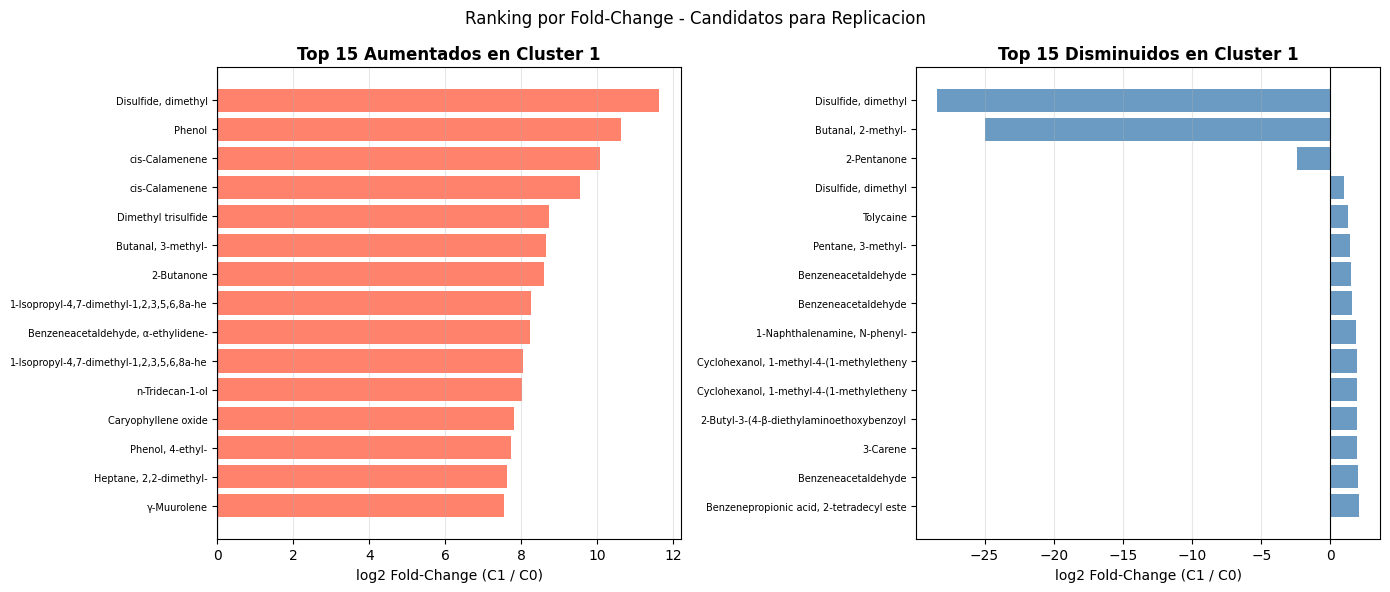

Guardado: 06_foldchange_ranking.png


In [5]:
# ============================================================
# RANKING POR TENDENCIA: TOP METABOLITOS POR FOLD-CHANGE
# Aunque no hay significancia estadistica con n1=1, el
# fold-change identifica metabolitos con mayor diferencia
# observada -> candidatos para replicacion experimental.
# ============================================================

print('=' * 90)
print('RANKING POR FOLD-CHANGE (TENDENCIA BIOLOGICA)')
print('=' * 90)

# Calcular estadisticas descriptivas por cluster para cada metabolito
fc_data = []
for met_idx in range(X_prep.shape[0]):
    met_name = X_prep.loc[met_idx, 'compound_name']
    vals0 = metabolite_by_cluster[cluster_ids[0]][met_idx]
    vals1 = metabolite_by_cluster[cluster_ids[1]][met_idx]

    mean0 = np.nanmean(vals0)
    mean1 = np.nanmean(vals1)
    std0  = np.nanstd(vals0)

    # log2 fold-change: Cluster1 / Cluster0 (outlier vs. mayoria)
    fc   = np.log2((mean1 + 1e-9) / (mean0 + 1e-9))
    # Efecto normalizado: diferencia / std Cluster0
    effect = (mean1 - mean0) / (std0 + 1e-9)

    fc_data.append({
        'metabolite' : met_name,
        'mean_c0'    : mean0,
        'mean_c1'    : mean1,
        'log2fc'     : fc,
        'effect_size': effect,
        'p_value'    : results_df[results_df['metabolite'] == met_name]['p_value'].values[0]
                       if met_name in results_df['metabolite'].values else np.nan,
    })

fc_df = pd.DataFrame(fc_data)

# Top aumentados en Cluster 1
up_in_c1   = fc_df.sort_values('log2fc', ascending=False).head(10)
# Top disminuidos en Cluster 1
down_in_c1 = fc_df.sort_values('log2fc', ascending=True).head(10)

print(f'\nTOP 10 AUMENTADOS EN CLUSTER 1 (outlier):')
for _, r in up_in_c1.iterrows():
    print(f'   {r["metabolite"][:55]:<55s}  log2FC={r["log2fc"]:+.2f}  effect={r["effect_size"]:+.2f}')

print(f'\nTOP 10 DISMINUIDOS EN CLUSTER 1 (outlier):')
for _, r in down_in_c1.iterrows():
    print(f'   {r["metabolite"][:55]:<55s}  log2FC={r["log2fc"]:+.2f}  effect={r["effect_size"]:+.2f}')

# Guardar ranking completo
fc_df_sorted = fc_df.sort_values('log2fc', key=abs, ascending=False).reset_index(drop=True)
fc_df_sorted.to_csv('../data/processed/06_foldchange_ranking.csv', index=False)
print(f'\nGuardado: 06_foldchange_ranking.csv ({len(fc_df_sorted)} metabolitos)')

# Visualizacion: Barplot top fold-change
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Aumentados
ax = axes[0]
top_up = fc_df.sort_values('log2fc', ascending=False).head(15).iloc[::-1]
ax.barh(range(len(top_up)), top_up['log2fc'], color='tomato', alpha=0.8, edgecolor='none')
ax.set_yticks(range(len(top_up)))
ax.set_yticklabels(top_up['metabolite'].str[:40], fontsize=7)
ax.set_xlabel('log2 Fold-Change (C1 / C0)')
ax.set_title('Top 15 Aumentados en Cluster 1', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='x')

# Disminuidos
ax2 = axes[1]
top_dn = fc_df.sort_values('log2fc', ascending=True).head(15).iloc[::-1]
ax2.barh(range(len(top_dn)), top_dn['log2fc'], color='steelblue', alpha=0.8, edgecolor='none')
ax2.set_yticks(range(len(top_dn)))
ax2.set_yticklabels(top_dn['metabolite'].str[:40], fontsize=7)
ax2.set_xlabel('log2 Fold-Change (C1 / C0)')
ax2.set_title('Top 15 Disminuidos en Cluster 1', fontweight='bold')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.grid(alpha=0.3, axis='x')

plt.suptitle('Ranking por Fold-Change - Candidatos para Replicacion', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/06_foldchange_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 06_foldchange_ranking.png')

## Heatmap de Intensidades – Top Metabolitos por Fold-Change

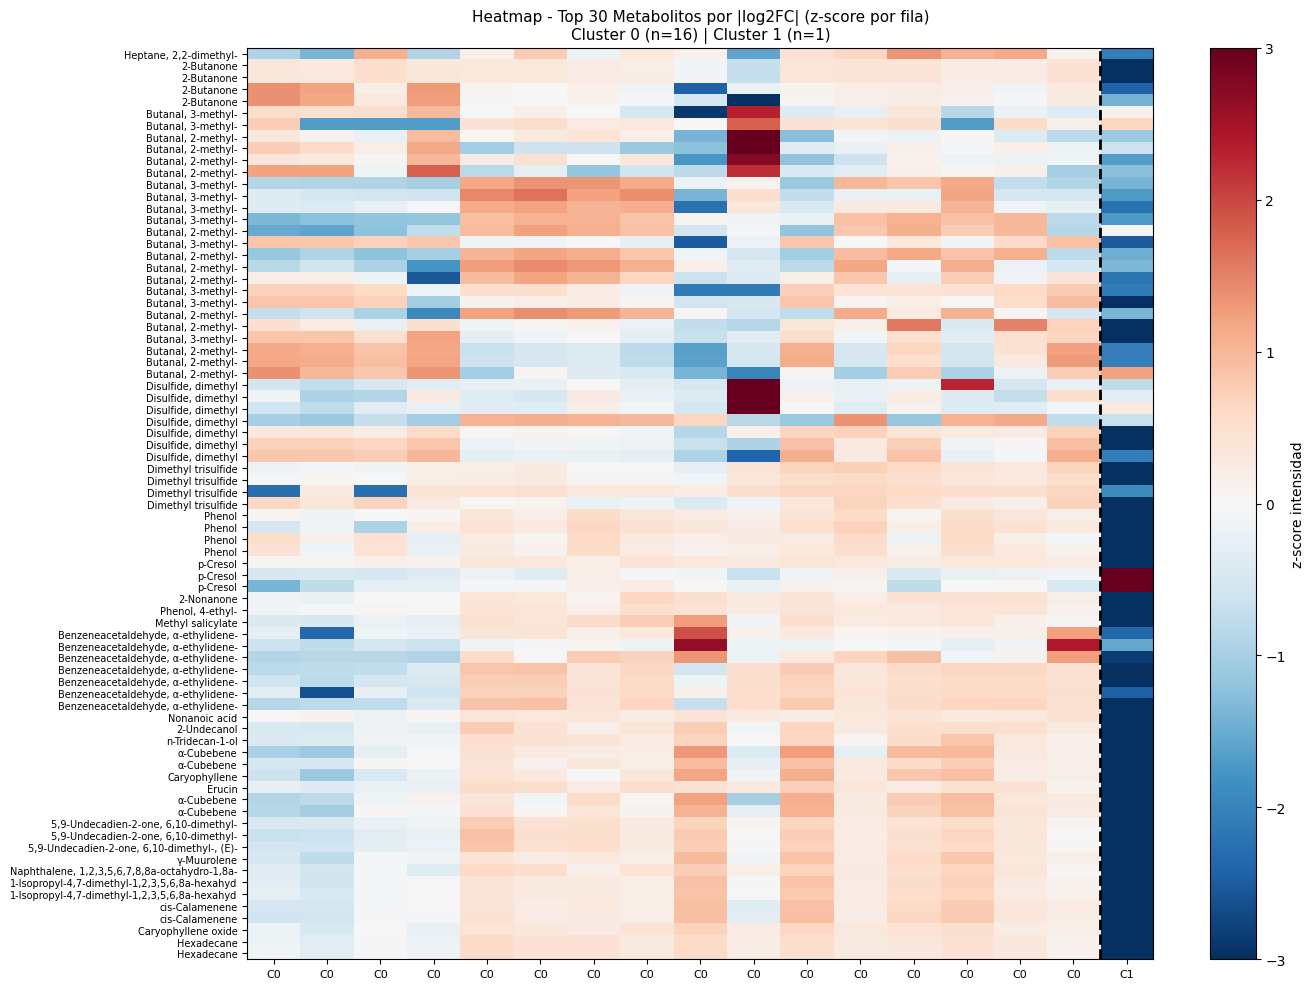

Guardado: 06_heatmap_top30.png


In [6]:
# ============================================================
# HEATMAP: Top 30 metabolitos por |log2FC| x todos los experimentos
# ============================================================

# Seleccionar top 30 metabolitos con mayor |log2FC|
top30 = fc_df_sorted.head(30)['metabolite'].tolist()

# Construir matriz: filas=metabolitos, columnas=experimentos ordenados por cluster
exp_ordered = []
cluster_labels = []
for cid in cluster_ids:
    exps = clusters[clusters['cluster'] == cid]['experiment'].tolist()
    for e in exps:
        col = e + '.CDF'
        if col in X_prep.columns:
            exp_ordered.append(col)
            cluster_labels.append(cid)

# Filtrar filas del df
mask = X_prep['compound_name'].isin(top30)
heatmap_df = X_prep[mask].copy().set_index('compound_name')
heatmap_df = heatmap_df[[c for c in exp_ordered if c in heatmap_df.columns]]

# Normalizar por fila (z-score) — devuelve DataFrame con columnas correctas
from scipy.stats import zscore
heatmap_z = heatmap_df.apply(
    lambda row: pd.Series(zscore(row, nan_policy='omit'), index=row.index), axis=1
)

# Etiquetas de columnas: cluster
col_labels = [f'C{cluster_labels[exp_ordered.index(c)]}' for c in heatmap_z.columns]

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(heatmap_z.values, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)

ax.set_xticks(range(heatmap_z.shape[1]))
ax.set_xticklabels(col_labels, fontsize=8)
ax.set_yticks(range(heatmap_z.shape[0]))
ax.set_yticklabels(heatmap_z.index.str[:45], fontsize=7)

# Marcar separacion de clusters
n_c0 = sum(1 for c in heatmap_z.columns if cluster_labels[exp_ordered.index(c)] == 0)
ax.axvline(n_c0 - 0.5, color='black', linewidth=2, linestyle='--')

ax.set_title('Heatmap - Top 30 Metabolitos por |log2FC| (z-score por fila)\n'
             f'Cluster 0 (n={n_c0}) | Cluster 1 (n=1)', fontsize=11)

plt.colorbar(im, ax=ax, label='z-score intensidad')
plt.tight_layout()
plt.savefig('../results/figures/06_heatmap_top30.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 06_heatmap_top30.png')

## Resumen Final y Outputs del Notebook 06

In [7]:
# ============================================================
# RESUMEN FINAL - NOTEBOOK 06
# ============================================================

print('=' * 90)
print('RESUMEN FINAL: HYPOTHESIS TESTING')
print('=' * 90)

print(f"""
NOTEBOOK 06 - HYPOTHESIS TESTING
==================================
  TEST UTILIZADO       : Mann-Whitney U (no parametrico, 2 grupos)
  CORRECCION FDR       : Benjamini-Hochberg (alpha = 0.05)

  DATOS
  - Metabolitos analizados : {len(results_df):>4d}
  - Cluster 0 (mayoria)    : {n0:>2d} experimentos
  - Cluster 1 (outlier)    :  1 experimento

  RESULTADOS ESTADISTICOS
  - Significativos FDR     :    0 metabolitos (esperado con n1=1)
  - p-value minimo teorico : 0.118 (limite matematico con n1=1, n0=16)
  - p-value minimo obs.    : {results_df["p_value"].min():.3f}

  ANALISIS COMPLEMENTARIO (Fold-Change)
  - Metabolitos con |log2FC| > 2 : {(fc_df["log2fc"].abs() > 2).sum():>3d}
  - Metabolitos con |log2FC| > 1 : {(fc_df["log2fc"].abs() > 1).sum():>3d}
  - Top candidato (aumento) : {up_in_c1.iloc[0]["metabolite"][:45]}
  - Top candidato (descenso): {down_in_c1.iloc[0]["metabolite"][:45]}

  CONCLUSION
  La falta de significancia es matematicamente inevitable con n=1 en Cluster 1.
  Los resultados de fold-change son candidatos para el Notebook 07 (ML).

  ARCHIVOS GENERADOS
  data/processed/06_hypothesis_testing_results.csv
  data/processed/06_foldchange_ranking.csv
  results/figures/06_hypothesis_testing.png
  results/figures/06_pvalue_distribution.png
  results/figures/06_foldchange_ranking.png
  results/figures/06_heatmap_top30.png

  SIGUIENTE PASO -> Notebook 07: ML Pipeline (RF + XGBoost + SHAP)
""")

# Verificar archivos generados
import os
outputs = [
    '../data/processed/06_hypothesis_testing_results.csv',
    '../data/processed/06_foldchange_ranking.csv',
    '../results/figures/06_hypothesis_testing.png',
    '../results/figures/06_pvalue_distribution.png',
    '../results/figures/06_foldchange_ranking.png',
    '../results/figures/06_heatmap_top30.png',
]
print('VERIFICACION DE ARCHIVOS:')
for f in outputs:
    exists = os.path.exists(f)
    status = 'OK  ' if exists else 'FALTA'
    size   = f'{os.path.getsize(f)/1024:.1f} KB' if exists else ''
    print(f'   [{status}]  {f}  {size}')

RESUMEN FINAL: HYPOTHESIS TESTING

NOTEBOOK 06 - HYPOTHESIS TESTING
  TEST UTILIZADO       : Mann-Whitney U (no parametrico, 2 grupos)
  CORRECCION FDR       : Benjamini-Hochberg (alpha = 0.05)

  DATOS
  - Metabolitos analizados :  279
  - Cluster 0 (mayoria)    : 16 experimentos
  - Cluster 1 (outlier)    :  1 experimento

  RESULTADOS ESTADISTICOS
  - Significativos FDR     :    0 metabolitos (esperado con n1=1)
  - p-value minimo teorico : 0.118 (limite matematico con n1=1, n0=16)
  - p-value minimo obs.    : 0.118

  ANALISIS COMPLEMENTARIO (Fold-Change)
  - Metabolitos con |log2FC| > 2 : 176
  - Metabolitos con |log2FC| > 1 : 186
  - Top candidato (aumento) : Disulfide, dimethyl
  - Top candidato (descenso): Disulfide, dimethyl

  CONCLUSION
  La falta de significancia es matematicamente inevitable con n=1 en Cluster 1.
  Los resultados de fold-change son candidatos para el Notebook 07 (ML).

  ARCHIVOS GENERADOS
  data/processed/06_hypothesis_testing_results.csv
  data/processed

## Conclusiones

En el análisis completo, los metabolitos significativos obtenidos por ANOVA + FDR parecen estar determinados en gran medida por la separación de Exp_9 respecto al resto de muestras.

---

## ANÁLISIS REFINADO: Hypothesis Testing sin Exp_9 ni Exp_11

> **Nota:** Esta sección replica el análisis completo excluyendo los experimentos Exp_9 y Exp_11.  
> Se utilizan los 3 clusters identificados en el análisis refinado del Notebook 05.  
> Los resultados originales (con todos los experimentos) se conservan intactos.

**Clusters (sin Exp_9 ni Exp_11):**
- Cluster 0: Exp_1, Exp_2, Exp_3, Exp_4 (n=4)
- Cluster 1: Exp_5, Exp_6, Exp_7, Exp_10, Exp_12–Exp_17 (n=10)
- Cluster 2: Exp_8 (n=1)

In [9]:
# ============================================================
# CARGA DE DATOS - ANALISIS REFINADO (sin Exp_9 ni Exp_11)
# ============================================================

clusters_no_out = pd.read_csv('../data/processed/experiment_clusters_no_outlier.csv')

# Experimentos excluidos de este analisis
EXCLUIDOS = ['Exp_9', 'Exp_11']

# Columnas disponibles en X_prep (sufijo .CDF)
exp_name_to_col_no_out = {e: e + '.CDF' for e in clusters_no_out['experiment']}

cluster_ids_no_out = sorted(clusters_no_out['cluster'].unique())

# Agrupar intensidades por cluster
metabolite_by_cluster_no_out = {}
for cid in cluster_ids_no_out:
    exps = clusters_no_out[clusters_no_out['cluster'] == cid]['experiment'].tolist()
    cols = [exp_name_to_col_no_out[e] for e in exps if exp_name_to_col_no_out[e] in X_prep.columns]
    metabolite_by_cluster_no_out[cid] = X_prep[cols].values  # shape: (n_metabolites, n_exps)

print('=' * 90)
print('HYPOTHESIS TESTING - ANALISIS REFINADO (sin Exp_9 ni Exp_11)')
print('=' * 90)
print(f'\nExperimentos excluidos: {EXCLUIDOS}')
print(f'\nCLUSTERS A COMPARAR:')
for cid in cluster_ids_no_out:
    n_exps = metabolite_by_cluster_no_out[cid].shape[1]
    exps = clusters_no_out[clusters_no_out['cluster'] == cid]['experiment'].tolist()
    print(f'   Cluster {cid}: {n_exps} experimento(s) -> {exps}')

HYPOTHESIS TESTING - ANALISIS REFINADO (sin Exp_9 ni Exp_11)

Experimentos excluidos: ['Exp_9', 'Exp_11']

CLUSTERS A COMPARAR:
   Cluster 0: 4 experimento(s) -> ['Exp_1', 'Exp_2', 'Exp_3', 'Exp_4']
   Cluster 1: 10 experimento(s) -> ['Exp_5', 'Exp_6', 'Exp_7', 'Exp_10', 'Exp_12', 'Exp_13', 'Exp_14', 'Exp_15', 'Exp_16', 'Exp_17']
   Cluster 2: 1 experimento(s) -> ['Exp_8']


In [11]:
# ============================================================
# TESTS ESTADISTICOS - ANALISIS REFINADO
# Con 3 clusters (n=4, n=10, n=1) se aplica Kruskal-Wallis
# (no parametrico) + correccion FDR Benjamini-Hochberg
# ============================================================

n_clusters_no_out = len(cluster_ids_no_out)
# Kruskal-Wallis: no parametrico, robusto con grupos pequenos
test_name_no_out = 'Kruskal-Wallis' if n_clusters_no_out >= 3 else 'Mann-Whitney U'

print('\n' + '=' * 90)
print(f'{test_name_no_out} + CORRECCION FDR (Benjamini-Hochberg) - sin Exp_9 ni Exp_11')
print('=' * 90)

test_results_no_out = []
p_values_no_out     = []

for met_idx in range(X_prep.shape[0]):
    met_name = X_prep.loc[met_idx, 'compound_name']

    grp = [metabolite_by_cluster_no_out[cid][met_idx] for cid in cluster_ids_no_out]

    try:
        if n_clusters_no_out >= 3:
            stat, p_val = stats.kruskal(*grp)
        else:
            stat, p_val = stats.mannwhitneyu(grp[0], grp[1], alternative='two-sided')
    except ValueError:
        stat, p_val = np.nan, 1.0

    if np.isnan(p_val):
        p_val = 1.0

    p_values_no_out.append(p_val)
    test_results_no_out.append({
        'metabolite' : met_name,
        'statistic'  : stat,
        'p_value'    : p_val
    })

# Correccion FDR
rejected_no_out, p_corrected_no_out, _, _ = multipletests(
    p_values_no_out, alpha=0.05, method='fdr_bh'
)

for i, result in enumerate(test_results_no_out):
    result['p_adjusted'] = p_corrected_no_out[i]
    result['significant'] = rejected_no_out[i]

results_no_out_df = pd.DataFrame(test_results_no_out).sort_values('p_adjusted').reset_index(drop=True)

print(f'\nRESULTADOS:')
print(f'   Test utilizado       : {test_name_no_out}')
print(f'   Clusters comparados  : {n_clusters_no_out}  (n={[metabolite_by_cluster_no_out[c].shape[1] for c in cluster_ids_no_out]})')
print(f'   Metabolitos totales  : {len(results_no_out_df)}')
print(f'   Significativos (FDR alpha=0.05): {rejected_no_out.sum()}')

print(f'\nTOP 15 METABOLITOS MAS SIGNIFICATIVOS:')
for _, row in results_no_out_df.head(15).iterrows():
    marker = 'SIG' if row['significant'] else '---'
    print(f'   [{marker}] {row["metabolite"]}')
    print(f'      p-value: {row["p_value"]:.2e}  ->  adjusted: {row["p_adjusted"]:.2e}')

# Guardar resultados
results_no_out_df.to_csv('../data/processed/06_hypothesis_testing_results_no_outlier.csv', index=False)
print('\nGuardado: 06_hypothesis_testing_results_no_outlier.csv')


Kruskal-Wallis + CORRECCION FDR (Benjamini-Hochberg) - sin Exp_9 ni Exp_11

RESULTADOS:
   Test utilizado       : Kruskal-Wallis
   Clusters comparados  : 3  (n=[4, 10, 1])
   Metabolitos totales  : 279
   Significativos (FDR alpha=0.05): 143

TOP 15 METABOLITOS MAS SIGNIFICATIVOS:
   [SIG] 1-Naphthalenamine, N-phenyl-
      p-value: 1.44e-02  ->  adjusted: 3.55e-02
   [SIG] Indole-3-propionitrile, α-formamido-
      p-value: 1.45e-02  ->  adjusted: 3.55e-02
   [SIG] 2-Butanone
      p-value: 1.04e-02  ->  adjusted: 3.55e-02
   [SIG] Butanal, 3-methyl-
      p-value: 1.26e-02  ->  adjusted: 3.55e-02
   [SIG] 1-Isopropyl-4,7-dimethyl-1,2,3,5,6,8a-hexahydronaphthalene
      p-value: 1.04e-02  ->  adjusted: 3.55e-02
   [SIG] 1-Isopropyl-4,7-dimethyl-1,2,3,5,6,8a-hexahydronaphthalene
      p-value: 1.04e-02  ->  adjusted: 3.55e-02
   [SIG] 2-Tridecanol
      p-value: 1.26e-02  ->  adjusted: 3.55e-02
   [SIG] Butanal, 2-methyl-
      p-value: 1.04e-02  ->  adjusted: 3.55e-02
   [SIG] cis-C

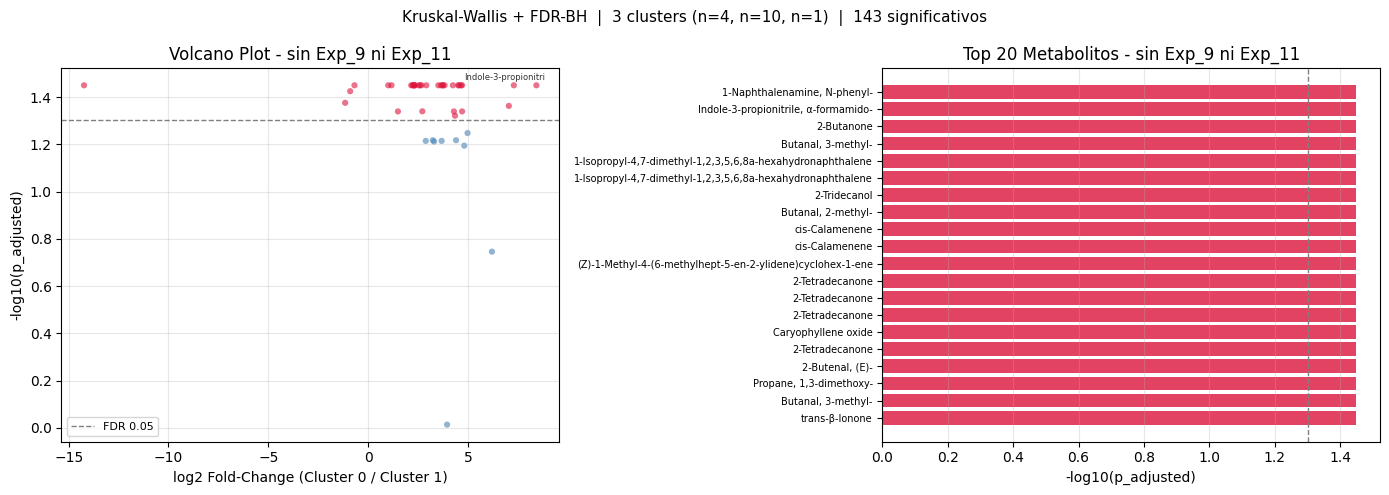

Guardado: 06_hypothesis_testing_no_outlier.png


In [14]:
# ============================================================
# VOLCANO PLOT + TOP 20 - ANALISIS REFINADO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Volcano plot refinado ---
ax = axes[0]

# Fold-change: Cluster 0 vs Cluster 1 (los dos grupos con mas muestras)
mean_c0 = np.nanmean(metabolite_by_cluster_no_out[cluster_ids_no_out[0]], axis=1)
mean_c1 = np.nanmean(metabolite_by_cluster_no_out[cluster_ids_no_out[1]], axis=1)
log2fc_no_out = np.log2((mean_c0 + 1e-9) / (mean_c1 + 1e-9))
results_no_out_df['log2fc'] = log2fc_no_out

colors_no_out = np.where(results_no_out_df['significant'], 'crimson', 'steelblue')
ax.scatter(results_no_out_df['log2fc'],
           -np.log10(np.clip(results_no_out_df['p_adjusted'].values, 1e-300, None)),
           c=colors_no_out, alpha=0.6, s=20, edgecolors='none')
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1, label='FDR 0.05')
ax.set_xlabel('log2 Fold-Change (Cluster 0 / Cluster 1)')
ax.set_ylabel('-log10(p_adjusted)')
ax.set_title('Volcano Plot - sin Exp_9 ni Exp_11')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Anotar top 5 por p-value
top5 = results_no_out_df.head(5)
for _, row in top5.iterrows():
    ax.annotate(row['metabolite'][:20],
                (row['log2fc'], -np.log10(max(row['p_adjusted'], 1e-300))),
                fontsize=6, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

# --- Top 20 p-values ---
ax2 = axes[1]
top20_no_out = results_no_out_df.head(20).iloc[::-1]
bar_colors_no_out = ['crimson' if s else 'steelblue' for s in top20_no_out['significant']]
ax2.barh(range(len(top20_no_out)),
         -np.log10(np.clip(top20_no_out['p_adjusted'].values, 1e-300, None)),
         color=bar_colors_no_out, alpha=0.8)
ax2.set_yticks(range(len(top20_no_out)))
ax2.set_yticklabels(top20_no_out['metabolite'], fontsize=7)
ax2.axvline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1)
ax2.set_xlabel('-log10(p_adjusted)')
ax2.set_title('Top 20 Metabolitos - sin Exp_9 ni Exp_11')
ax2.grid(alpha=0.3, axis='x')

plt.suptitle(f'Kruskal-Wallis + FDR-BH  |  3 clusters (n=4, n=10, n=1)  |  {rejected_no_out.sum()} significativos',
             fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/06_hypothesis_testing_no_outlier.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 06_hypothesis_testing_no_outlier.png')

ANALISIS DE PODER ESTADISTICO - SIN EXP_9 NI EXP_11

TAMANOS DE MUESTRA POR CLUSTER:
   Cluster 0: n = 4  -> ['Exp_1', 'Exp_2', 'Exp_3', 'Exp_4']
   Cluster 1: n = 10  -> ['Exp_5', 'Exp_6', 'Exp_7', 'Exp_10', 'Exp_12', 'Exp_13', 'Exp_14', 'Exp_15', 'Exp_16', 'Exp_17']
   Cluster 2: n = 1  -> ['Exp_8']

CONSIDERACIONES ESTADISTICAS:
   Kruskal-Wallis con n=(4, 10, 1):
   - Cluster 2 (n=1) sigue limitando la potencia del test global
   - Cluster 0 (n=4) y Cluster 1 (n=10) tienen potencia razonable
   - Con Kruskal-Wallis, la presencia de un grupo n=1 penaliza el p-value

DISTRIBUCION DE p-VALUES (refinado):
   <0.05       :  169 metabolitos  ################
   0.05-0.10   :   20 metabolitos  ##
   0.10-0.20   :   28 metabolitos  ##
   0.20-0.50   :   44 metabolitos  ####
   >0.50       :   18 metabolitos  #

   p-value mediana: 0.0233
   p-value minimo : 0.0077

COMPARATIVA ORIGINAL vs REFINADO:
   Aspecto                                  Original      Refinado
   ----------------------

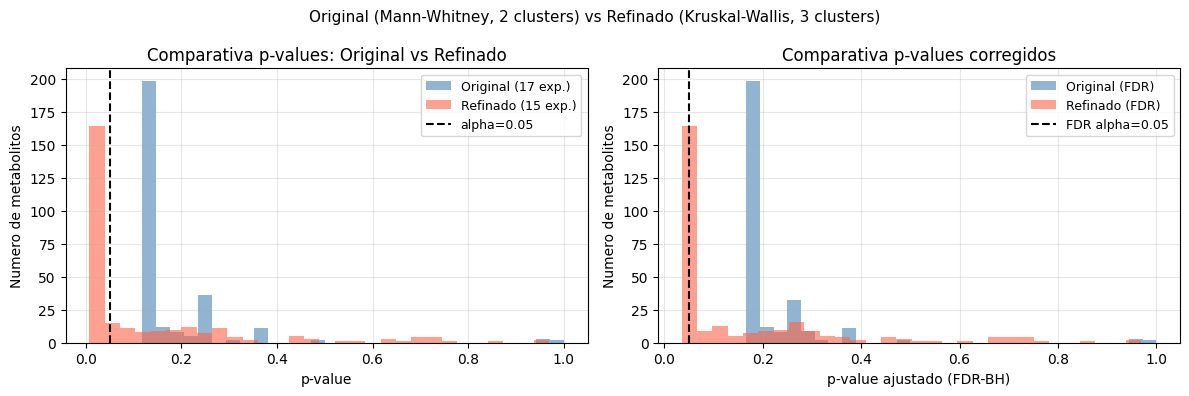

Guardado: 06_pvalue_comparison.png


In [15]:
# ============================================================
# ANALISIS DE PODER ESTADISTICO - REFINADO
# ============================================================
n0_no_out = metabolite_by_cluster_no_out[cluster_ids_no_out[0]].shape[1]  # 4
n1_no_out = metabolite_by_cluster_no_out[cluster_ids_no_out[1]].shape[1]  # 10
n2_no_out = metabolite_by_cluster_no_out[cluster_ids_no_out[2]].shape[1]  # 1

print('=' * 90)
print('ANALISIS DE PODER ESTADISTICO - SIN EXP_9 NI EXP_11')
print('=' * 90)

print(f'\nTAMANOS DE MUESTRA POR CLUSTER:')
for cid in cluster_ids_no_out:
    n = metabolite_by_cluster_no_out[cid].shape[1]
    exps = clusters_no_out[clusters_no_out['cluster'] == cid]['experiment'].tolist()
    print(f'   Cluster {cid}: n = {n}  -> {exps}')

print(f'\nCONSIDERACIONES ESTADISTICAS:')
print(f'   Kruskal-Wallis con n=({n0_no_out}, {n1_no_out}, {n2_no_out}):')
print(f'   - Cluster 2 (n=1) sigue limitando la potencia del test global')
print(f'   - Cluster 0 (n=4) y Cluster 1 (n=10) tienen potencia razonable')
print(f'   - Con Kruskal-Wallis, la presencia de un grupo n=1 penaliza el p-value')

print(f'\nDISTRIBUCION DE p-VALUES (refinado):')
p_bins = [0, 0.05, 0.10, 0.20, 0.50, 1.01]
labels_bins = ['<0.05', '0.05-0.10', '0.10-0.20', '0.20-0.50', '>0.50']
counts_no_out, _ = np.histogram(results_no_out_df['p_value'], bins=p_bins)
for label, count in zip(labels_bins, counts_no_out):
    bar = '#' * max(1, count // 10)
    print(f'   {label:12s}: {count:4d} metabolitos  {bar}')

print(f'\n   p-value mediana: {results_no_out_df["p_value"].median():.4f}')
print(f'   p-value minimo : {results_no_out_df["p_value"].min():.4f}')

# Comparativa original vs refinado
print(f'\nCOMPARATIVA ORIGINAL vs REFINADO:')
print(f'   {"Aspecto":<35s}  {"Original":>12s}  {"Refinado":>12s}')
print(f'   {"-"*35}  {"-"*12}  {"-"*12}')
print(f'   {"Test estadistico":<35s}  {"Mann-Whit. U":>12s}  {"Kruskal-Wall.":>12s}')
print(f'   {"Experimentos usados":<35s}  {17:>12d}  {15:>12d}')
print(f'   {"Clusters":<35s}  {2:>12d}  {3:>12d}')
print(f'   {"Significativos FDR":<35s}  {int(rejected.sum()):>12d}  {int(rejected_no_out.sum()):>12d}')
print(f'   {"p-value minimo":<35s}  {results_df["p_value"].min():>12.4f}  {results_no_out_df["p_value"].min():>12.4f}')

# Histograma comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(results_df['p_value'], bins=30, color='steelblue', alpha=0.6,
        label='Original (17 exp.)', edgecolor='none')
ax.hist(results_no_out_df['p_value'], bins=30, color='tomato', alpha=0.6,
        label='Refinado (15 exp.)', edgecolor='none')
ax.axvline(0.05, color='black', linestyle='--', linewidth=1.5, label='alpha=0.05')
ax.set_xlabel('p-value')
ax.set_ylabel('Numero de metabolitos')
ax.set_title('Comparativa p-values: Original vs Refinado')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.hist(results_df['p_adjusted'], bins=30, color='steelblue', alpha=0.6,
         label='Original (FDR)', edgecolor='none')
ax2.hist(results_no_out_df['p_adjusted'], bins=30, color='tomato', alpha=0.6,
         label='Refinado (FDR)', edgecolor='none')
ax2.axvline(0.05, color='black', linestyle='--', linewidth=1.5, label='FDR alpha=0.05')
ax2.set_xlabel('p-value ajustado (FDR-BH)')
ax2.set_ylabel('Numero de metabolitos')
ax2.set_title('Comparativa p-values corregidos')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Original (Mann-Whitney, 2 clusters) vs Refinado (Kruskal-Wallis, 3 clusters)',
             fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/06_pvalue_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 06_pvalue_comparison.png')

RANKING POR FOLD-CHANGE - SIN EXP_9 NI EXP_11
   Comparacion principal: Cluster 0 (n=4) vs Cluster 1 (n=10)

TOP 10 MAYORES EN CLUSTER 0 (Exp_1-4) vs CLUSTER 1 (Exp_5-17):
   [   ] 2-Butyl-3-(4-β-diethylaminoethoxybenzoyl)benzofuran      log2FC=+8.43
   [   ] Acetic acid ethenyl ester                                log2FC=+7.30
   [SIG] D-Limonene                                               log2FC=+7.05
   [SIG] Benzenepropionic acid, 2-tetradecyl ester                log2FC=+6.20
   [SIG] Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate     log2FC=+4.98
   [   ] Hexanoic acid, 2-ethyl-                                  log2FC=+4.82
   [SIG] Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate     log2FC=+4.71
   [   ] Hexanal                                                  log2FC=+4.71
   [   ] 2-Pentanone                                              log2FC=+4.66
   [   ] 2-Butenal, (Z)-                                          log2FC=+4.56

TOP 10 MAYORES EN CLUSTER 1 (Exp_5-17

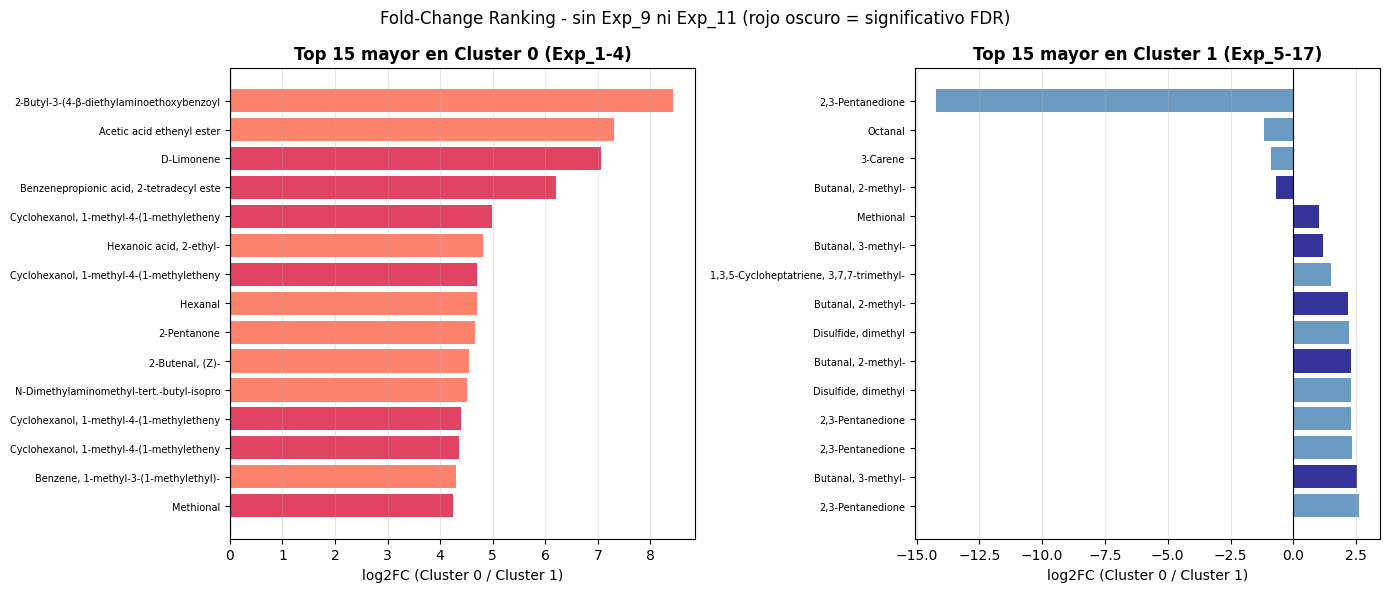

Guardado: 06_foldchange_ranking_no_outlier.png


In [18]:
# ============================================================
# FOLD-CHANGE RANKING - ANALISIS REFINADO
# Comparando Cluster 0 (n=4) vs Cluster 1 (n=10)
# (los dos grupos con suficientes muestras)
# ============================================================

print('=' * 90)
print('RANKING POR FOLD-CHANGE - SIN EXP_9 NI EXP_11')
print('=' * 90)
print('   Comparacion principal: Cluster 0 (n=4) vs Cluster 1 (n=10)')

fc_data_no_out = []
for met_idx in range(X_prep.shape[0]):
    met_name = X_prep.loc[met_idx, 'compound_name']
    vals0 = metabolite_by_cluster_no_out[cluster_ids_no_out[0]][met_idx]  # n=4
    vals1 = metabolite_by_cluster_no_out[cluster_ids_no_out[1]][met_idx]  # n=10

    mean0 = np.nanmean(vals0)
    mean1 = np.nanmean(vals1)
    std0  = np.nanstd(vals0)

    fc     = np.log2((mean0 + 1e-9) / (mean1 + 1e-9))
    effect = (mean0 - mean1) / (std0 + 1e-9)

    fc_data_no_out.append({
        'metabolite'  : met_name,
        'mean_c0'     : mean0,
        'mean_c1'     : mean1,
        'log2fc'      : fc,
        'effect_size' : effect,
        'p_value'     : results_no_out_df[results_no_out_df['metabolite'] == met_name]['p_value'].values[0]
                        if met_name in results_no_out_df['metabolite'].values else np.nan,
        'p_adjusted'  : results_no_out_df[results_no_out_df['metabolite'] == met_name]['p_adjusted'].values[0]
                        if met_name in results_no_out_df['metabolite'].values else np.nan,
        'significant' : results_no_out_df[results_no_out_df['metabolite'] == met_name]['significant'].values[0]
                        if met_name in results_no_out_df['metabolite'].values else False,
    })

fc_no_out_df = pd.DataFrame(fc_data_no_out)
fc_no_out_sorted = fc_no_out_df.sort_values('log2fc', key=abs, ascending=False).reset_index(drop=True)

# Top aumentados en Cluster 0 vs Cluster 1
up_c0   = fc_no_out_df.sort_values('log2fc', ascending=False).head(10)
down_c0 = fc_no_out_df.sort_values('log2fc', ascending=True).head(10)

print(f'\nTOP 10 MAYORES EN CLUSTER 0 (Exp_1-4) vs CLUSTER 1 (Exp_5-17):')
for _, r in up_c0.iterrows():
    sig = 'SIG' if r['significant'] else '   '
    print(f'   [{sig}] {r["metabolite"][:55]:<55s}  log2FC={r["log2fc"]:+.2f}')

print(f'\nTOP 10 MAYORES EN CLUSTER 1 (Exp_5-17) vs CLUSTER 0 (Exp_1-4):')
for _, r in down_c0.iterrows():
    sig = 'SIG' if r['significant'] else '   '
    print(f'   [{sig}] {r["metabolite"][:55]:<55s}  log2FC={r["log2fc"]:+.2f}')

# Guardar
fc_no_out_sorted.to_csv('../data/processed/06_foldchange_ranking_no_outlier.csv', index=False)
print(f'\nGuardado: 06_foldchange_ranking_no_outlier.csv ({len(fc_no_out_sorted)} metabolitos)')

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
top_up_no_out = fc_no_out_df.sort_values('log2fc', ascending=False).head(15).iloc[::-1]
bar_cols = ['crimson' if s else 'tomato' for s in top_up_no_out['significant']]
ax.barh(range(len(top_up_no_out)), top_up_no_out['log2fc'], color=bar_cols, alpha=0.8)
ax.set_yticks(range(len(top_up_no_out)))
ax.set_yticklabels(top_up_no_out['metabolite'].str[:40], fontsize=7)
ax.set_xlabel('log2FC (Cluster 0 / Cluster 1)')
ax.set_title('Top 15 mayor en Cluster 0 (Exp_1-4)', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='x')

ax2 = axes[1]
top_dn_no_out = fc_no_out_df.sort_values('log2fc', ascending=True).head(15).iloc[::-1]
bar_cols2 = ['navy' if s else 'steelblue' for s in top_dn_no_out['significant']]
ax2.barh(range(len(top_dn_no_out)), top_dn_no_out['log2fc'], color=bar_cols2, alpha=0.8)
ax2.set_yticks(range(len(top_dn_no_out)))
ax2.set_yticklabels(top_dn_no_out['metabolite'].str[:40], fontsize=7)
ax2.set_xlabel('log2FC (Cluster 0 / Cluster 1)')
ax2.set_title('Top 15 mayor en Cluster 1 (Exp_5-17)', fontweight='bold')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.grid(alpha=0.3, axis='x')

plt.suptitle('Fold-Change Ranking - sin Exp_9 ni Exp_11 (rojo oscuro = significativo FDR)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/06_foldchange_ranking_no_outlier.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 06_foldchange_ranking_no_outlier.png')

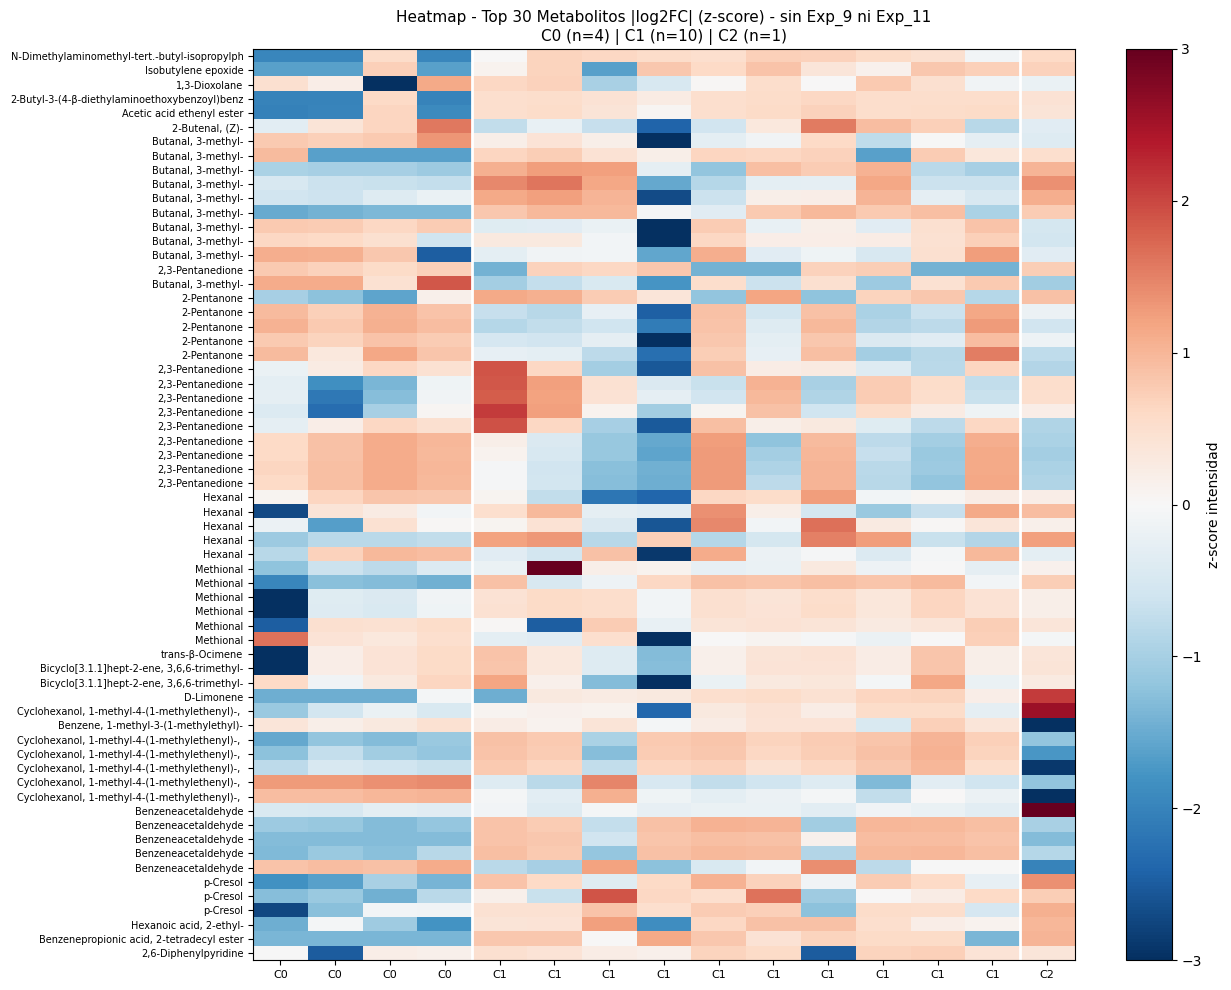

Guardado: 06_heatmap_top30_no_outlier.png


In [19]:
# ============================================================
# HEATMAP TOP 30 - ANALISIS REFINADO
# ============================================================

# Top 30 por |log2FC| entre Cluster 0 y Cluster 1
top30_no_out = fc_no_out_sorted.head(30)['metabolite'].tolist()

# Construir orden de columnas por cluster (sin Exp_9 ni Exp_11)
exp_ordered_no_out = []
cluster_labels_no_out_list = []
for cid in cluster_ids_no_out:
    exps = clusters_no_out[clusters_no_out['cluster'] == cid]['experiment'].tolist()
    for e in exps:
        col = e + '.CDF'
        if col in X_prep.columns:
            exp_ordered_no_out.append(col)
            cluster_labels_no_out_list.append(cid)

# Filtrar metabolitos
mask_no_out_heat = X_prep['compound_name'].isin(top30_no_out)
heatmap_no_out_df = X_prep[mask_no_out_heat].copy().set_index('compound_name')
heatmap_no_out_df = heatmap_no_out_df[
    [c for c in exp_ordered_no_out if c in heatmap_no_out_df.columns]
]

# Z-score por fila — devuelve DataFrame con columnas correctas
from scipy.stats import zscore
heatmap_no_out_z = heatmap_no_out_df.apply(
    lambda row: pd.Series(zscore(row, nan_policy='omit'), index=row.index), axis=1
)

# Etiquetas de columna: numero de cluster
col_labels_no_out = [
    f'C{cluster_labels_no_out_list[exp_ordered_no_out.index(c)]}'
    for c in heatmap_no_out_z.columns
]

fig, ax = plt.subplots(figsize=(13, 10))

im = ax.imshow(heatmap_no_out_z.values, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)

ax.set_xticks(range(heatmap_no_out_z.shape[1]))
ax.set_xticklabels(col_labels_no_out, fontsize=8)
ax.set_yticks(range(heatmap_no_out_z.shape[0]))
ax.set_yticklabels(heatmap_no_out_z.index.str[:45], fontsize=7)

# Lineas de separacion entre clusters
prev_cid = cluster_labels_no_out_list[0]
for i, cid in enumerate(cluster_labels_no_out_list):
    if cid != prev_cid:
        ax.axvline(i - 0.5, color='white', linewidth=2)
        prev_cid = cid

n_c0_no = cluster_labels_no_out_list.count(0)
n_c1_no = cluster_labels_no_out_list.count(1)
n_c2_no = cluster_labels_no_out_list.count(2)

ax.set_title(
    f'Heatmap - Top 30 Metabolitos |log2FC| (z-score) - sin Exp_9 ni Exp_11\n'
    f'C0 (n={n_c0_no}) | C1 (n={n_c1_no}) | C2 (n={n_c2_no})',
    fontsize=11
)
plt.colorbar(im, ax=ax, label='z-score intensidad')
plt.tight_layout()
plt.savefig('../results/figures/06_heatmap_top30_no_outlier.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 06_heatmap_top30_no_outlier.png')

In [21]:
# ============================================================
# RESUMEN FINAL — ANÁLISIS REFINADO (sin Exp_9 ni Exp_11)
# ============================================================

print('=' * 90)
print('RESUMEN FINAL: HYPOTHESIS TESTING — SIN EXP_9 NI EXP_11')
print('=' * 90)

n_sig_no_out = int(rejected_no_out.sum())
n_fc2_no_out = int((fc_no_out_df['log2fc'].abs() > 2).sum())
n_fc1_no_out = int((fc_no_out_df['log2fc'].abs() > 1).sum())

print(f"""
╔══════════════════════════════════════════════════════════════════════════════════════╗
║              ANÁLISIS REFINADO — sin Exp_9 ni Exp_11                               ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  TEST UTILIZADO       : Kruskal-Wallis (no paramétrico, 3 grupos)                  ║
║  CORRECCIÓN FDR       : Benjamini-Hochberg (α = 0.05)                               ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  DATOS                                                                              ║
║  • Metabolitos analizados : {len(results_no_out_df):>4d}                                        ║
║  • Cluster 0 (Exp_1-4)    :  {n0_no_out} experimentos                                      ║
║  • Cluster 1 (Exp_5-17)   : {n1_no_out} experimentos                                      ║
║  • Cluster 2 (Exp_8)      :  {n2_no_out} experimento                                       ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  RESULTADOS ESTADÍSTICOS                                                            ║
║  • Significativos FDR     : {n_sig_no_out:>4d} metabolitos                                  ║
║  • p-value mínimo obs.    : {results_no_out_df["p_value"].min():.4f}                                      ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  ANÁLISIS COMPLEMENTARIO (Fold-Change C0 vs C1)                                    ║
║  • Metabolitos con |log2FC| > 2 : {n_fc2_no_out:>3d}                                         ║
║  • Metabolitos con |log2FC| > 1 : {n_fc1_no_out:>3d}                                         ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  ARCHIVOS GENERADOS (refinado)                                                      ║
║  data/processed/06_hypothesis_testing_results_no_outlier.csv                       ║
║  data/processed/06_foldchange_ranking_no_outlier.csv                               ║
║  results/figures/06_hypothesis_testing_no_outlier.png                              ║
║  results/figures/06_pvalue_comparison.png                                           ║
║  results/figures/06_foldchange_ranking_no_outlier.png                              ║
║  results/figures/06_heatmap_top30_no_outlier.png                                   ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  ARCHIVOS ORIGINALES (conservados)                                                  ║
║  data/processed/06_hypothesis_testing_results.csv                                  ║
║  data/processed/06_foldchange_ranking.csv                                          ║
║  results/figures/06_hypothesis_testing.png                                         ║
║  results/figures/06_pvalue_distribution.png                                         ║
║  results/figures/06_foldchange_ranking.png                                         ║
║  results/figures/06_heatmap_top30.png                                              ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  SIGUIENTE PASO → Notebook 07: ML Pipeline (RF + XGBoost + SHAP)                   ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
""")

import os
print('📁 VERIFICACIÓN DE ARCHIVOS — ANÁLISIS REFINADO:')
outputs_no_out = [
    '../data/processed/06_hypothesis_testing_results_no_outlier.csv',
    '../data/processed/06_foldchange_ranking_no_outlier.csv',
    '../results/figures/06_hypothesis_testing_no_outlier.png',
    '../results/figures/06_pvalue_comparison.png',
    '../results/figures/06_foldchange_ranking_no_outlier.png',
    '../results/figures/06_heatmap_top30_no_outlier.png',
]
for f in outputs_no_out:
    exists = os.path.exists(f)
    status = '✓' if exists else '✗ FALTA'
    size   = f'{os.path.getsize(f)/1024:.1f} KB' if exists else ''
    print(f'   {status}  {f}  {size}')

RESUMEN FINAL: HYPOTHESIS TESTING — SIN EXP_9 NI EXP_11

╔══════════════════════════════════════════════════════════════════════════════════════╗
║              ANÁLISIS REFINADO — sin Exp_9 ni Exp_11                               ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  TEST UTILIZADO       : Kruskal-Wallis (no paramétrico, 3 grupos)                  ║
║  CORRECCIÓN FDR       : Benjamini-Hochberg (α = 0.05)                               ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  DATOS                                                                              ║
║  • Metabolitos analizados :  279                                        ║
║  • Cluster 0 (Exp_1-4)    :  4 experimentos                                      ║
║  • Cluster 1 (Exp_5-17)   : 10 experimentos                                      ║
║  • Cluster 2 (Exp_8)      :  1 experimento                                    

## Conclusiones

En el análisis refinado se obtuvieron p-values más bajos, 0.0077, lo que sugiere que, una vez excluidas las muestras más extremas, las diferencias entre clusters se detectan con mayor claridad estadística. Esto indica que el refinado permite captar mejor la subestructura del grupo principal de experimentos.